In [ ]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor


train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)


print(f"Training dataset size: {len(train_data)}")
print(f"Testing dataset size: {len(test_data)}")
print(f"Classes: {train_data.classes}\n")


image, label = train_data[0]
print(f"Single image tensor shape: {image.shape} -> [Channels, Height, Width]")
print(f"Label for this image: {label}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.15MB/s]

Training dataset size: 60000
Testing dataset size: 10000
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']

Single image tensor shape: torch.Size([1, 28, 28]) -> [Channels, Height, Width]
Label for this image: 5


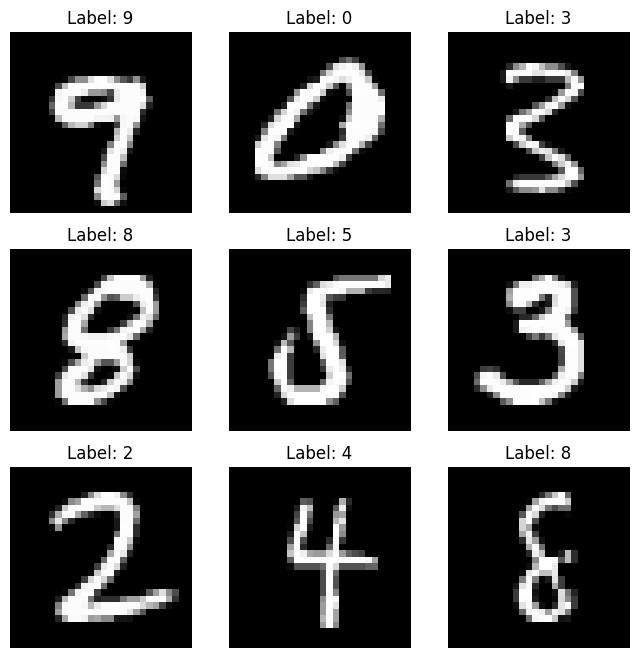

In [ ]:
import matplotlib.pyplot as plt


figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):

    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]

    figure.add_subplot(rows, cols, i)
    plt.title(f"Label: {label}")
    plt.axis("off")


    plt.imshow(img.squeeze(), cmap="gray")

plt.show()

In [6]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=mnist_transform)
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=mnist_transform)


train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)


images, labels = next(iter(train_loader))


print(f"Batch images tensor shape: {images.shape} -> Expected: [64, 1:channel, 28:height, 28:width]")
print(f"Batch labels tensor shape: {labels.shape} -> Expected: [64]")

Batch images tensor shape: torch.Size([64, 1, 28, 28]) -> Expected: [64, 1:channel, 28:height, 28:width]
Batch labels tensor shape: torch.Size([64]) -> Expected: [64]


In [7]:
import torch.nn as nn

class MNISTCNN(nn.Module):
    def __init__(self):
        super(MNISTCNN, self).__init__()


        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()

        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)


        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


        self.dropout = nn.Dropout(p=0.25)


        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()


        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))


        x = x.view(x.size(0), -1)


        x = self.dropout(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)

        return x

model = MNISTCNN()

print(model)


output = model(images)

print(f"Model output tensor shape: {output.shape} -> Expected: [64:batch_size, 10:classes]")

MNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Model output tensor shape: torch.Size([64, 10]) -> Expected: [64:batch_size, 10:classes]
